# Model Evaluation
This notebook evaluates the machine learning models trained on the full dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import joblib
import os

# Ensure current working directory is the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../../")

INPUT_PATH = "data/processed/cleaned_data.csv"
MODELS_DIR = "models/"
TARGET = "has_heart_disease"


### Data Preparation

In [ ]:
df = pd.read_csv(INPUT_PATH)
FEATURES = [c for c in df.columns if c != TARGET]
X = df[FEATURES]
y = df[TARGET]

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": joblib.load(os.path.join(MODELS_DIR, "logistic_regression.joblib")),
    "Random Forest": joblib.load(os.path.join(MODELS_DIR, "random_forest.joblib")),
}
xgb_path = os.path.join(MODELS_DIR, "xgboost.joblib")
if os.path.exists(xgb_path):
    models["XGBoost"] = joblib.load(xgb_path)

results = []

### Evaluation Metrics & Confusion Matrices

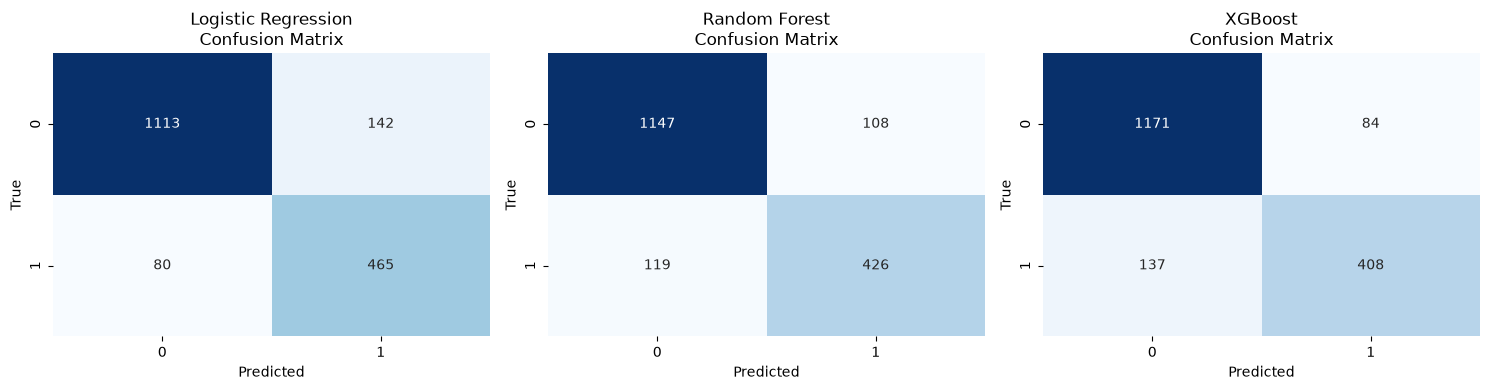

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1: axes = [axes]

for idx, (name, model) in enumerate(models.items()):
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

### Final Results Report

In [ ]:
results_df = pd.DataFrame(results).round(4)
display(results_df)

best = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f"\nBest Model: {best['Model']} (ROC-AUC: {best['ROC-AUC']})")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8767,0.7661,0.8532,0.8073,0.9498
1,Random Forest,0.8739,0.7978,0.7817,0.7896,0.9358
2,XGBoost,0.8772,0.8293,0.7486,0.7869,0.9366



Best Model: Logistic Regression (ROC-AUC: 0.9498)
